# Module 1 — Knowledge Graph Construction

**GraphRAG for Supply Chain Risk Intelligence**

---

## What this notebook does

This is the foundation of the entire project. By the end of this notebook we will have:

1. A curated synthetic supply chain corpus with known ground-truth relationships
2. Extracted supply chain entities (suppliers, manufacturers, ports, regions, parts, disruptions)
3. Typed relationship triples: `(head, relation, tail)`
4. A deduplicated, canonicalized entity registry
5. A directed NetworkX knowledge graph with typed nodes and edges
6. Node embeddings stored in a FAISS index for semantic retrieval in Module 2
7. Validation statistics and visualizations

## GenAI concepts covered

| Concept | Where |
|---|---|
| **Encoder-only models** | spaCy's NER (transformer-based) + sentence-transformers for embeddings |
| **Embeddings** | Every graph node gets a dense vector via `sentence-transformers` |
| **Transformer architecture** | Under the hood of both spaCy and sentence-transformers |

---

## 0. Environment Setup

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# Uncomment the line below if running for the first time in a fresh environment

# !pip install networkx sentence-transformers faiss-cpu spacy pyvis matplotlib
# !python -m spacy download en_core_web_sm

In [2]:
# ── Standard imports ──────────────────────────────────────────────────────────
import sys
import json
import pickle
from pathlib import Path
from pprint import pprint

import networkx as nx
import matplotlib.pyplot as plt

# Add project root to path so src.* imports resolve correctly
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Project imports ───────────────────────────────────────────────────────────
from src.graph.schema import (
    EntityType, RelationType, Entity, Triple,
    ENTITY_TYPES, RELATION_TYPES,
    NODE_ATTR_TYPE, EDGE_ATTR_RELATION, EDGE_ATTR_WEIGHT,
)

from src.graph.builder       import KnowledgeGraphBuilder
from src.graph.disambiguator import EntityDisambiguator
from src.embeddings.encoder  import NodeEncoder
from src.utils.visualization import plot_graph, plot_ego_subgraph

# ── Output directories ────────────────────────────────────────────────────────
DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
OUTPUTS        = Path("../outputs/graphs")

for d in [DATA_RAW, DATA_PROCESSED, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

print("✓ Environment ready")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  Python       : {sys.version.split()[0]}")

/opt/anaconda3/envs/genAI-project/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


✓ Environment ready
  Project root : /Users/baddou/Desktop/ENG-Cycle-S4/Generative_AI/Project/GraphRAG-in-Supply-Chain
  Python       : 3.10.20


---

## Step 1 — Build the Synthetic Supply Chain Corpus

We construct a realistic synthetic corpus that mirrors what you would find in:
- Supplier onboarding documents
- Procurement reports
- Industry news articles about SC disruptions

**Why synthetic?** Using a known corpus lets us define precise ground-truth triples
for evaluation in Module 5. The SupplyGraph dataset (Wasi et al.) can be swapped
in later with zero code changes.

The corpus covers an **electric vehicle supply chain** — chosen because:
- It has deep multi-tier dependencies (lithium → battery → EV manufacturer)
- It has real, documented geopolitical risk (Taiwan semiconductors, Congo cobalt)
- It directly mirrors the Almahri et al. (2024) paper's domain

In [3]:
# ── Synthetic supply chain corpus ─────────────────────────────────────────────
#
# Each document is a dict with "text" and "source" keys.
# The text is written to contain known entity mentions and relation patterns
# so we can later verify extraction quality against this ground truth.

SYNTHETIC_CORPUS: list[dict] = [

    # --- Tier 1: semiconductor supply chain ---
    {
        "source": "supplier_profile_tsmc",
        "text": (
            "TSMC, headquartered in Taiwan, is the world's largest semiconductor "
            "foundry. TSMC supplies advanced chips to Apple, NVIDIA, and AMD. "
            "Taiwan Semiconductor Manufacturing depends on ASML for extreme "
            "ultraviolet lithography machines. ASML is based in the Netherlands. "
            "TSMC ships through the Port of Kaohsiung to reach customers in the "
            "United States and Europe."
        ),
    },
    {
        "source": "risk_report_taiwan_semiconductor",
        "text": (
            "The 2024 Taiwan Earthquake severely affected semiconductor production "
            "in Taiwan. TSMC was affected by the Taiwan Earthquake. "
            "GlobalFoundries, headquartered in the United States, is an alternative "
            "to TSMC for mature-node chip production. "
            "Samsung Foundry, located in South Korea, is also an alternative to TSMC "
            "for advanced logic chips."
        ),
    },

    # --- Tier 2: battery and EV supply chain ---
    {
        "source": "supplier_profile_catl",
        "text": (
            "CATL, headquartered in China, is the world's largest battery manufacturer. "
            "CATL supplies lithium-ion battery packs to Tesla, BMW, and Volkswagen. "
            "CATL depends on lithium carbonate sourced from Chile and Argentina. "
            "The company ships through the Port of Shanghai to European customers. "
            "Ganfeng Lithium, located in China, supplies lithium to CATL."
        ),
    },
    {
        "source": "supplier_profile_panasonic",
        "text": (
            "Panasonic Energy, based in Japan, manufactures cylindrical battery cells. "
            "Panasonic Energy supplies battery cells to Tesla through the Gigafactory "
            "Nevada joint venture. Panasonic depends on cobalt sourced from the "
            "Democratic Republic of Congo. "
            "POSCO, located in South Korea, is an alternative to Panasonic "
            "for battery-grade nickel supply."
        ),
    },

    # --- Tier 3: raw materials ---
    {
        "source": "commodity_report_lithium",
        "text": (
            "Ganfeng Lithium is headquartered in Jiangxi, China. "
            "Ganfeng Lithium supplies lithium hydroxide to BMW, Tesla, and LG Energy. "
            "Ganfeng Lithium sources lithium from the Atacama Desert in Chile. "
            "Pilbara Minerals, located in Australia, is an alternative to Ganfeng Lithium "
            "for hard-rock lithium spodumene."
        ),
    },
    {
        "source": "commodity_report_cobalt",
        "text": (
            "Glencore, headquartered in Switzerland, is a major cobalt supplier. "
            "Glencore supplies cobalt to battery manufacturers including CATL and Panasonic. "
            "Glencore sources cobalt from the Katanga Mining Complex in the Democratic "
            "Republic of Congo. The Congo Cobalt Strike of 2023 affected production "
            "at the Katanga Mining Complex. "
            "Glencore was affected by the Congo Cobalt Strike."
        ),
    },

    # --- OEM / Manufacturer tier ---
    {
        "source": "oem_profile_tesla",
        "text": (
            "Tesla manufactures electric vehicles at its Gigafactory in Texas. "
            "Tesla depends on TSMC for automotive-grade chips. "
            "Tesla depends on CATL and Panasonic Energy for battery cells. "
            "Tesla sells electric vehicles to customers across North America and Europe. "
            "Tesla ships finished vehicles through the Port of Los Angeles."
        ),
    },
    {
        "source": "oem_profile_apple",
        "text": (
            "Apple designs consumer electronics and is headquartered in the United States. "
            "Apple depends on TSMC for A-series and M-series chips. "
            "Apple ships products through the Port of Shanghai and the Port of Los Angeles. "
            "Foxconn, located in Taiwan, manufactures iPhones for Apple. "
            "Apple sells consumer devices to customers worldwide."
        ),
    },

    # --- Logistics and disruption events ---
    {
        "source": "logistics_report_suez",
        "text": (
            "The Red Sea Shipping Disruption of 2024 forced many carriers to reroute "
            "around the Cape of Good Hope. The Port of Rotterdam was affected by "
            "the Red Sea Shipping Disruption. "
            "Maersk, headquartered in Denmark, routes container ships through the "
            "Suez Canal Corridor. Maersk was affected by the Red Sea Shipping Disruption. "
            "The Port of Singapore serves as an alternative to the Suez Canal Corridor "
            "for Asian-European trade."
        ),
    },
    {
        "source": "disruption_report_shanghai_lockdown",
        "text": (
            "The Shanghai Lockdown of 2022 caused severe supply chain disruptions "
            "across the global electronics industry. "
            "The Port of Shanghai was affected by the Shanghai Lockdown. "
            "CATL was affected by the Shanghai Lockdown due to its manufacturing "
            "facilities located in China. "
            "The Port of Ningbo is an alternative to the Port of Shanghai for "
            "exports from eastern China."
        ),
    },
]

# Save to disk as raw data
raw_path = DATA_RAW / "synthetic_sc_corpus.json"
raw_path.write_text(json.dumps(SYNTHETIC_CORPUS, indent=2))

print(f"✓ Corpus created: {len(SYNTHETIC_CORPUS)} documents")
print(f"  Saved to: {raw_path}")
print(f"\n  Documents:")
for doc in SYNTHETIC_CORPUS:
    print(f"    - {doc['source']}")

✓ Corpus created: 10 documents
  Saved to: ../data/raw/synthetic_sc_corpus.json

  Documents:
    - supplier_profile_tsmc
    - risk_report_taiwan_semiconductor
    - supplier_profile_catl
    - supplier_profile_panasonic
    - commodity_report_lithium
    - commodity_report_cobalt
    - oem_profile_tesla
    - oem_profile_apple
    - logistics_report_suez
    - disruption_report_shanghai_lockdown


### Ground-truth triple inventory

We define the expected triples so we can measure extraction recall in the validation step. (Maybe can be done in the future with an LLM wrapper that parses the raw data and defines relations ?)

In [4]:
# ── Ground-truth triples for evaluation ───────────────────────────────────────
# Format: (head, relation, tail)
# These are the canonical facts we expect the pipeline to extract.

GROUND_TRUTH_TRIPLES: list[tuple[str, str, str]] = [
    # TSMC cluster
    ("TSMC",             "located_in",   "Taiwan"),
    ("TSMC",             "supplies",     "Apple"),
    ("TSMC",             "supplies",     "NVIDIA"),
    ("TSMC",             "supplies",     "AMD"),
    ("TSMC",             "depends_on",   "ASML"),
    ("TSMC",             "ships_through","Port of Kaohsiung"),
    ("TSMC",             "affected_by",  "Taiwan Earthquake"),
    ("GlobalFoundries",  "alternative_to","TSMC"),
    ("Samsung Foundry",  "alternative_to","TSMC"),

    # CATL cluster
    ("CATL",             "located_in",   "China"),
    ("CATL",             "supplies",     "Tesla"),
    ("CATL",             "supplies",     "BMW"),
    ("CATL",             "supplies",     "Volkswagen"),
    ("CATL",             "ships_through","Port of Shanghai"),
    ("Ganfeng Lithium",  "supplies",     "CATL"),
    ("CATL",             "affected_by",  "Shanghai Lockdown"),

    # Panasonic / Glencore cluster
    ("Panasonic Energy", "supplies",     "Tesla"),
    ("Panasonic Energy", "depends_on",   "cobalt"),
    ("Glencore",         "supplies",     "CATL"),
    ("Glencore",         "supplies",     "Panasonic Energy"),
    ("Glencore",         "affected_by",  "Congo Cobalt Strike"),

    # Tesla cluster
    ("Tesla",            "depends_on",   "TSMC"),
    ("Tesla",            "depends_on",   "CATL"),
    ("Tesla",            "ships_through","Port of Los Angeles"),

    # Apple cluster
    ("Apple",            "depends_on",   "TSMC"),
    ("Apple",            "ships_through","Port of Shanghai"),

    # Logistics / disruptions
    ("Maersk",           "affected_by",  "Red Sea Shipping Disruption"),
    ("Port of Rotterdam","affected_by",  "Red Sea Shipping Disruption"),
    ("Port of Shanghai", "affected_by",  "Shanghai Lockdown"),
]

print(f"✓ Ground-truth inventory: {len(GROUND_TRUTH_TRIPLES)} triples defined")
print(f"\nSample triples:")
for t in GROUND_TRUTH_TRIPLES[:6]:
    print(f"  ({t[0]!r:30s} --[{t[1]:15s}]--> {t[2]!r})")

✓ Ground-truth inventory: 29 triples defined

Sample triples:
  ('TSMC'                         --[located_in     ]--> 'Taiwan')
  ('TSMC'                         --[supplies       ]--> 'Apple')
  ('TSMC'                         --[supplies       ]--> 'NVIDIA')
  ('TSMC'                         --[supplies       ]--> 'AMD')
  ('TSMC'                         --[depends_on     ]--> 'ASML')
  ('TSMC'                         --[ships_through  ]--> 'Port of Kaohsiung')


---

## Step 2 — Entity Extraction (NER)

We use **spaCy's transformer-based NER** as the backbone (encoder-only model)
and augment it with supply-chain-specific signal keywords defined in `builder.py`.

This is our first direct use of a **transformer encoder** — spaCy's `en_core_web_sm`
is a distilled transformer that produces contextual token representations.

In [5]:
# ── Initialize the builder and run entity extraction ─────────────────────────

builder = KnowledgeGraphBuilder(
    spacy_model="en_core_web_sm",
    confidence_threshold=0.5,
)

builder.load_documents(SYNTHETIC_CORPUS)
builder.extract_entities()

print(f"\n✓ Raw entities extracted: {len(builder.raw_entities)}")

[Disambiguator] Loading embedding model: all-MiniLM-L6-v2
[Builder] Loaded 10 document(s)
[Builder] Extracted 102 raw entities

✓ Raw entities extracted: 102


In [6]:
# ── Inspect extracted entities by type ───────────────────────────────────────

from collections import Counter

type_counter = Counter(e.entity_type.value for e in builder.raw_entities)

print("Entity type distribution:")
print("-" * 35)
for etype, count in sorted(type_counter.items(), key=lambda x: -x[1]):
    bar = "█" * count
    print(f"  {etype:25s} {count:3d}  {bar}")

print(f"\nSample raw entities:")
for ent in builder.raw_entities[:12]:
    print(f"  [{ent.entity_type.value:15s}] {ent.name!r}")

Entity type distribution:
-----------------------------------
  Region                     36  ████████████████████████████████████
  Supplier                   25  █████████████████████████
  Manufacturer               19  ███████████████████
  Port                       10  ██████████
  DisruptionEvent             8  ████████
  Part                        2  ██
  LogisticsRoute              2  ██

Sample raw entities:
  [Supplier       ] 'TSMC'
  [Region         ] 'Taiwan'
  [Supplier       ] 'TSMC'
  [Manufacturer   ] 'Apple'
  [Part           ] 'NVIDIA'
  [Part           ] 'AMD'
  [Supplier       ] 'Taiwan Semiconductor Manufacturing'
  [Supplier       ] 'ASML'
  [Supplier       ] 'ASML'
  [Region         ] 'Netherlands'
  [Supplier       ] 'TSMC'
  [Port           ] 'the Port of Kaohsiung'


---

## Step 3 — Triple Extraction (Relation Extraction)

For each sentence containing two or more entities, we apply **regex relation patterns**
to identify the relationship type. Confidence is scored heuristically based on the
positional alignment of head, pattern, and tail.

In a production system (Module B), this step would be replaced or augmented with
a fine-tuned BERT-based relation classifier.

In [7]:
# ── Extract triples ───────────────────────────────────────────────────────────

builder.extract_triples()

print(f"\n✓ Triples extracted: {len(builder.triples)}")
print(f"\nRelation type distribution:")
print("-" * 35)

rel_counter = Counter(t.relation.value for t in builder.triples)
for rel, count in sorted(rel_counter.items(), key=lambda x: -x[1]):
    bar = "█" * count
    print(f"  {rel:20s} {count:3d}  {bar}")

[Builder] Extracted 60 triples (threshold >= 0.5)

✓ Triples extracted: 60

Relation type distribution:
-----------------------------------
  supplies              19  ███████████████████
  located_in            15  ███████████████
  alternative_to         9  █████████
  ships_through          8  ████████
  depends_on             6  ██████
  affected_by            3  ███


In [8]:
# ── Display extracted triples ─────────────────────────────────────────────────

print("Extracted triples (sorted by confidence desc):")
print("-" * 70)

for t in sorted(builder.triples, key=lambda x: -x.confidence)[:20]:
    print(f"  conf={t.confidence:.2f}  {t.head!r:25s} --[{t.relation.value:15s}]--> {t.tail!r}")

Extracted triples (sorted by confidence desc):
----------------------------------------------------------------------
  conf=0.85  'TSMC'                    --[located_in     ]--> 'Taiwan'
  conf=0.85  'TSMC'                    --[supplies       ]--> 'Apple'
  conf=0.85  'TSMC'                    --[supplies       ]--> 'NVIDIA'
  conf=0.85  'TSMC'                    --[supplies       ]--> 'AMD'
  conf=0.85  'Taiwan Semiconductor Manufacturing' --[depends_on     ]--> 'ASML'
  conf=0.85  'ASML'                    --[located_in     ]--> 'Netherlands'
  conf=0.85  'TSMC'                    --[ships_through  ]--> 'the Port of Kaohsiung'
  conf=0.85  'TSMC'                    --[ships_through  ]--> 'the United States'
  conf=0.85  'TSMC'                    --[ships_through  ]--> 'Europe'
  conf=0.85  'TSMC'                    --[affected_by    ]--> 'the Taiwan Earthquake'
  conf=0.85  'GlobalFoundries'         --[located_in     ]--> 'the United States'
  conf=0.85  'GlobalFoundries'         

---

## Step 4 — Entity Disambiguation

Raw NER produces aliases like `"TSMC"`, `"Taiwan Semiconductor"`, and
`"Taiwan Semiconductor Manufacturing"` as separate entities. The disambiguator
merges these into a single canonical node.

**Two-pass strategy:**
1. String normalization (cheap, catches exact matches after cleaning)
2. Sentence-transformer cosine similarity (catches paraphrases)

This is our second use of an **encoder-only model** — the sentence-transformer
encodes entity name strings into a shared embedding space where similar names
cluster together.

In [9]:
# ── Run disambiguation ────────────────────────────────────────────────────────

builder.disambiguate()

print(f"\n✓ Disambiguation complete")
print(f"  Raw entities    : {len(builder.raw_entities)}")
print(f"  Canonical entities: {len(builder.canonical_entities)}")
print(f"  Reduction       : {len(builder.raw_entities) - len(builder.canonical_entities)} aliases merged")

[Disambiguator] 102 raw entities → 51 canonical entities
[Builder] After disambiguation: 51 canonical entities, 60 triples

✓ Disambiguation complete
  Raw entities    : 102
  Canonical entities: 51
  Reduction       : 51 aliases merged


In [10]:
# ── Inspect alias resolutions ─────────────────────────────────────────────────

alias_map = builder.disambiguator.alias_to_canonical

# Find entities with multiple aliases (most interesting cases)
canonical_to_aliases: dict[str, list[str]] = {}
for alias, canonical in alias_map.items():
    canonical_to_aliases.setdefault(canonical, []).append(alias)

print("Entities with merged aliases:")
print("-" * 50)
for canonical, aliases in canonical_to_aliases.items():
    if len(aliases) > 1:
        print(f"  Canonical: {canonical!r}")
        for a in aliases:
            if a != canonical.lower():
                print(f"    ← {a!r}")

Entities with merged aliases:
--------------------------------------------------


---

## Step 5 — Build the Knowledge Graph

All canonical entities become **nodes** and all triples become **directed edges**
in a NetworkX `DiGraph`. Node and edge attributes follow the schema defined
in `src/graph/schema.py`.

In [11]:
# ── Build the graph ───────────────────────────────────────────────────────────

G = builder.build_graph()
builder.assign_edge_weights()

stats = builder.graph_stats()

print("\n✓ Graph construction complete")
print("\nGraph statistics:")
print("-" * 35)
print(f"  Nodes                  : {stats['nodes']}")
print(f"  Edges                  : {stats['edges']}")
print(f"  Avg out-degree         : {stats['avg_out_degree']}")
print(f"  Weakly connected       : {stats['is_weakly_connected']}")
print(f"  Connected components   : {stats['weakly_connected_components']}")
print(f"\n  Node types:")
for etype, count in sorted(stats['node_types'].items(), key=lambda x: -x[1]):
    print(f"    {etype:25s}: {count}")
print(f"\n  Relation types:")
for rel, count in sorted(stats['relation_types'].items(), key=lambda x: -x[1]):
    print(f"    {rel:20s}: {count}")

[Builder] Graph built — 51 nodes, 60 edges
[Builder] Edge weights assigned

✓ Graph construction complete

Graph statistics:
-----------------------------------
  Nodes                  : 51
  Edges                  : 60
  Avg out-degree         : 1.18
  Weakly connected       : False
  Connected components   : 15

  Node types:
    Region                   : 23
    Supplier                 : 10
    Manufacturer             : 6
    Port                     : 6
    DisruptionEvent          : 3
    Part                     : 2
    LogisticsRoute           : 1

  Relation types:
    supplies            : 19
    located_in          : 15
    alternative_to      : 9
    ships_through       : 8
    depends_on          : 6
    affected_by         : 3


In [12]:
# ── Inspect a sample node ─────────────────────────────────────────────────────

sample_node = "TSMC"

if sample_node in G:
    print(f"Node: {sample_node!r}")
    print(f"  Attributes : {G.nodes[sample_node]}")
    print(f"  Out-edges  :")
    for _, target, data in G.out_edges(sample_node, data=True):
        print(f"    → {target!r:25s} [{data['relation']:15s}] weight={data['weight']:.2f}")
    print(f"  In-edges   :")
    for source, _, data in G.in_edges(sample_node, data=True):
        print(f"    ← {source!r:25s} [{data['relation']:15s}]")
else:
    print(f"Node {sample_node!r} not found. Available nodes: {list(G.nodes())[:10]}")

Node: 'TSMC'
  Attributes : {'entity_type': 'Supplier', 'aliases': ['TSMC', 'TSMC', 'TSMC', 'TSMC', 'TSMC', 'TSMC', 'TSMC'], 'metadata': {'spacy_label': 'ORG', 'source': 'supplier_profile_tsmc'}}
  Out-edges  :
    → 'Taiwan'                  [located_in     ] weight=1.00
    → 'Apple'                   [supplies       ] weight=1.00
    → 'NVIDIA'                  [supplies       ] weight=1.00
    → 'AMD'                     [supplies       ] weight=1.00
    → 'the Port of Kaohsiung'   [ships_through  ] weight=1.00
    → 'the United States'       [ships_through  ] weight=1.00
    → 'Europe'                  [ships_through  ] weight=1.00
    → 'the Taiwan Earthquake'   [affected_by    ] weight=1.00
  In-edges   :
    ← 'GlobalFoundries'         [located_in     ]
    ← 'the United States'       [alternative_to ]
    ← 'South Korea'             [alternative_to ]
    ← 'Tesla'                   [depends_on     ]
    ← 'Apple'                   [depends_on     ]


---

## Step 6 — Node Embeddings & FAISS Index

Every node is encoded with `sentence-transformers` (`all-MiniLM-L6-v2`).

The text fed to the encoder is: `"<EntityType>: <node_name>"` — the type prefix
is crucial for disambiguation in embedding space ("Supplier: TSMC" and
"Region: Taiwan" should cluster differently even though both contain "Taiwan").

This is the **embeddings** concept from the course: dense vector representations
that capture semantic meaning and enable similarity-based retrieval.

In [13]:
# ── Encode all graph nodes ────────────────────────────────────────────────────

encoder = NodeEncoder(model_name="all-MiniLM-L6-v2")
encoder.encode_graph(G)

# Save the FAISS index and node name list to disk
faiss_path = DATA_PROCESSED / "faiss_index.bin"
encoder.save_index(faiss_path)

print(f"\n✓ Node embeddings generated")
print(f"  Embedding dimension : {encoder.dim}")
print(f"  FAISS index size    : {len(encoder._node_names)} vectors")

# Verify an embedding was attached to a node
import numpy as np
sample_emb = G.nodes["TSMC"].get("embedding")
if sample_emb is not None:
    print(f"  TSMC embedding shape: {sample_emb.shape}")
    print(f"  TSMC embedding norm : {np.linalg.norm(sample_emb):.4f}  (should be ≈1.0 after normalization)")

[Encoder] Loading model: all-MiniLM-L6-v2
[Encoder] Encoding 51 nodes in batches of 64...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Encoder] Done. Embedding dim: 384, FAISS index size: 51
[Encoder] Index saved → ../data/processed/faiss_index.bin
[Encoder] Node names saved → ../data/processed/faiss_index.bin.names

✓ Node embeddings generated
  Embedding dimension : 384
  FAISS index size    : 51 vectors
  TSMC embedding shape: (384,)
  TSMC embedding norm : 1.0000  (should be ≈1.0 after normalization)


In [14]:
# ── Test semantic search ──────────────────────────────────────────────────────
# This is a preview of what Module 2 will use as its seed-node retrieval.

test_queries = [
    "semiconductor chip manufacturing",
    "disruption and earthquake risk",
    "lithium battery raw materials",
    "shipping and logistics hub",
]

print("Semantic search preview (top-3 nodes per query):")
print("=" * 60)

for query in test_queries:
    results = encoder.search(query, k=3)
    print(f"\n  Query: {query!r}")
    for rank, (node, score) in enumerate(results, 1):
        etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
        print(f"    {rank}. {node!r:30s} [{etype:15s}] sim={score:.4f}")

Semantic search preview (top-3 nodes per query):

  Query: 'semiconductor chip manufacturing'
    1. 'Taiwan Semiconductor Manufacturing' [Supplier       ] sim=0.5969
    2. 'iPhones'                      [Manufacturer   ] sim=0.4234
    3. 'Apple'                        [Manufacturer   ] sim=0.3899

  Query: 'disruption and earthquake risk'
    1. 'The Shanghai Lockdown'        [DisruptionEvent] sim=0.4873
    2. 'the Taiwan Earthquake'        [Region         ] sim=0.4722
    3. 'The Red Sea Shipping Disruption' [DisruptionEvent] sim=0.4699

  Query: 'lithium battery raw materials'
    1. 'Tesla'                        [Manufacturer   ] sim=0.2490
    2. 'LG Energy'                    [Supplier       ] sim=0.2315
    3. 'Pilbara Minerals'             [Supplier       ] sim=0.2263

  Query: 'shipping and logistics hub'
    1. 'the Suez Canal Corridor'      [LogisticsRoute ] sim=0.4999
    2. 'The Red Sea Shipping Disruption' [DisruptionEvent] sim=0.4679
    3. 'GlobalFoundries'         

---

## Step 7 — Validation

We measure **triple extraction recall** against the ground-truth inventory defined
in Step 1. This gives us a baseline NLP quality metric that Module B (BERT
fine-tuning) will aim to improve.

In [15]:
# ── Compute extraction precision and recall ───────────────────────────────────

def normalize_triple(h, r, t):
    """Lowercase and strip for fuzzy comparison."""
    return (h.lower().strip(), r.lower().strip(), t.lower().strip())

# Build sets of normalized triples
predicted_set = set(
    normalize_triple(t.head, t.relation.value, t.tail)
    for t in builder.triples
)

ground_truth_set = set(
    normalize_triple(h, r, t)
    for h, r, t in GROUND_TRUTH_TRIPLES
)

# Resolve predicted triples through the alias map (so "Taiwan Semiconductor" → "TSMC")
alias_map = builder.disambiguator.alias_to_canonical

def resolve_triple(h, r, t):
    """Resolve head and tail to canonical names if possible."""
    import re, unicodedata
    def norm(s):
        s = unicodedata.normalize("NFD", s).encode("ascii","ignore").decode()
        return re.sub(r"[^\w\s]"," ",s).lower().strip()
    canon_h = alias_map.get(norm(h), h)
    canon_t = alias_map.get(norm(t), t)
    return normalize_triple(canon_h, r, canon_t)

resolved_predicted = set(
    resolve_triple(t.head, t.relation.value, t.tail)
    for t in builder.triples
)

# Compute metrics
hits        = resolved_predicted & ground_truth_set
precision   = len(hits) / len(resolved_predicted) if resolved_predicted else 0
recall      = len(hits) / len(ground_truth_set)   if ground_truth_set   else 0
f1          = (2 * precision * recall / (precision + recall)
               if (precision + recall) > 0 else 0)

print("Triple Extraction Evaluation")
print("=" * 45)
print(f"  Ground truth triples : {len(ground_truth_set)}")
print(f"  Predicted triples    : {len(resolved_predicted)}")
print(f"  Correct hits         : {len(hits)}")
print(f"  Precision            : {precision:.2%}")
print(f"  Recall               : {recall:.2%}")
print(f"  F1                   : {f1:.2%}")

print(f"\n  ✓ Correctly extracted:")
for h, r, t in sorted(hits):
    print(f"    ({h!r:25s} --[{r:15s}]--> {t!r})")

missed = ground_truth_set - resolved_predicted
if missed:
    print(f"\n  ✗ Missed (will improve with fine-tuning in Module B):")
    for h, r, t in sorted(missed):
        print(f"    ({h!r:25s} --[{r:15s}]--> {t!r})")

Triple Extraction Evaluation
  Ground truth triples : 29
  Predicted triples    : 60
  Correct hits         : 8
  Precision            : 13.33%
  Recall               : 27.59%
  F1                   : 17.98%

  ✓ Correctly extracted:
    ('apple'                   --[depends_on     ]--> 'tsmc')
    ('panasonic energy'        --[supplies       ]--> 'tesla')
    ('tesla'                   --[depends_on     ]--> 'catl')
    ('tesla'                   --[depends_on     ]--> 'tsmc')
    ('tsmc'                    --[located_in     ]--> 'taiwan')
    ('tsmc'                    --[supplies       ]--> 'amd')
    ('tsmc'                    --[supplies       ]--> 'apple')
    ('tsmc'                    --[supplies       ]--> 'nvidia')

  ✗ Missed (will improve with fine-tuning in Module B):
    ('apple'                   --[ships_through  ]--> 'port of shanghai')
    ('catl'                    --[affected_by    ]--> 'shanghai lockdown')
    ('catl'                    --[located_in     ]--> 'chin

---

## Step 8 — Graph Visualization

[Viz] Plot saved → ../outputs/graphs/module1_full_graph.png


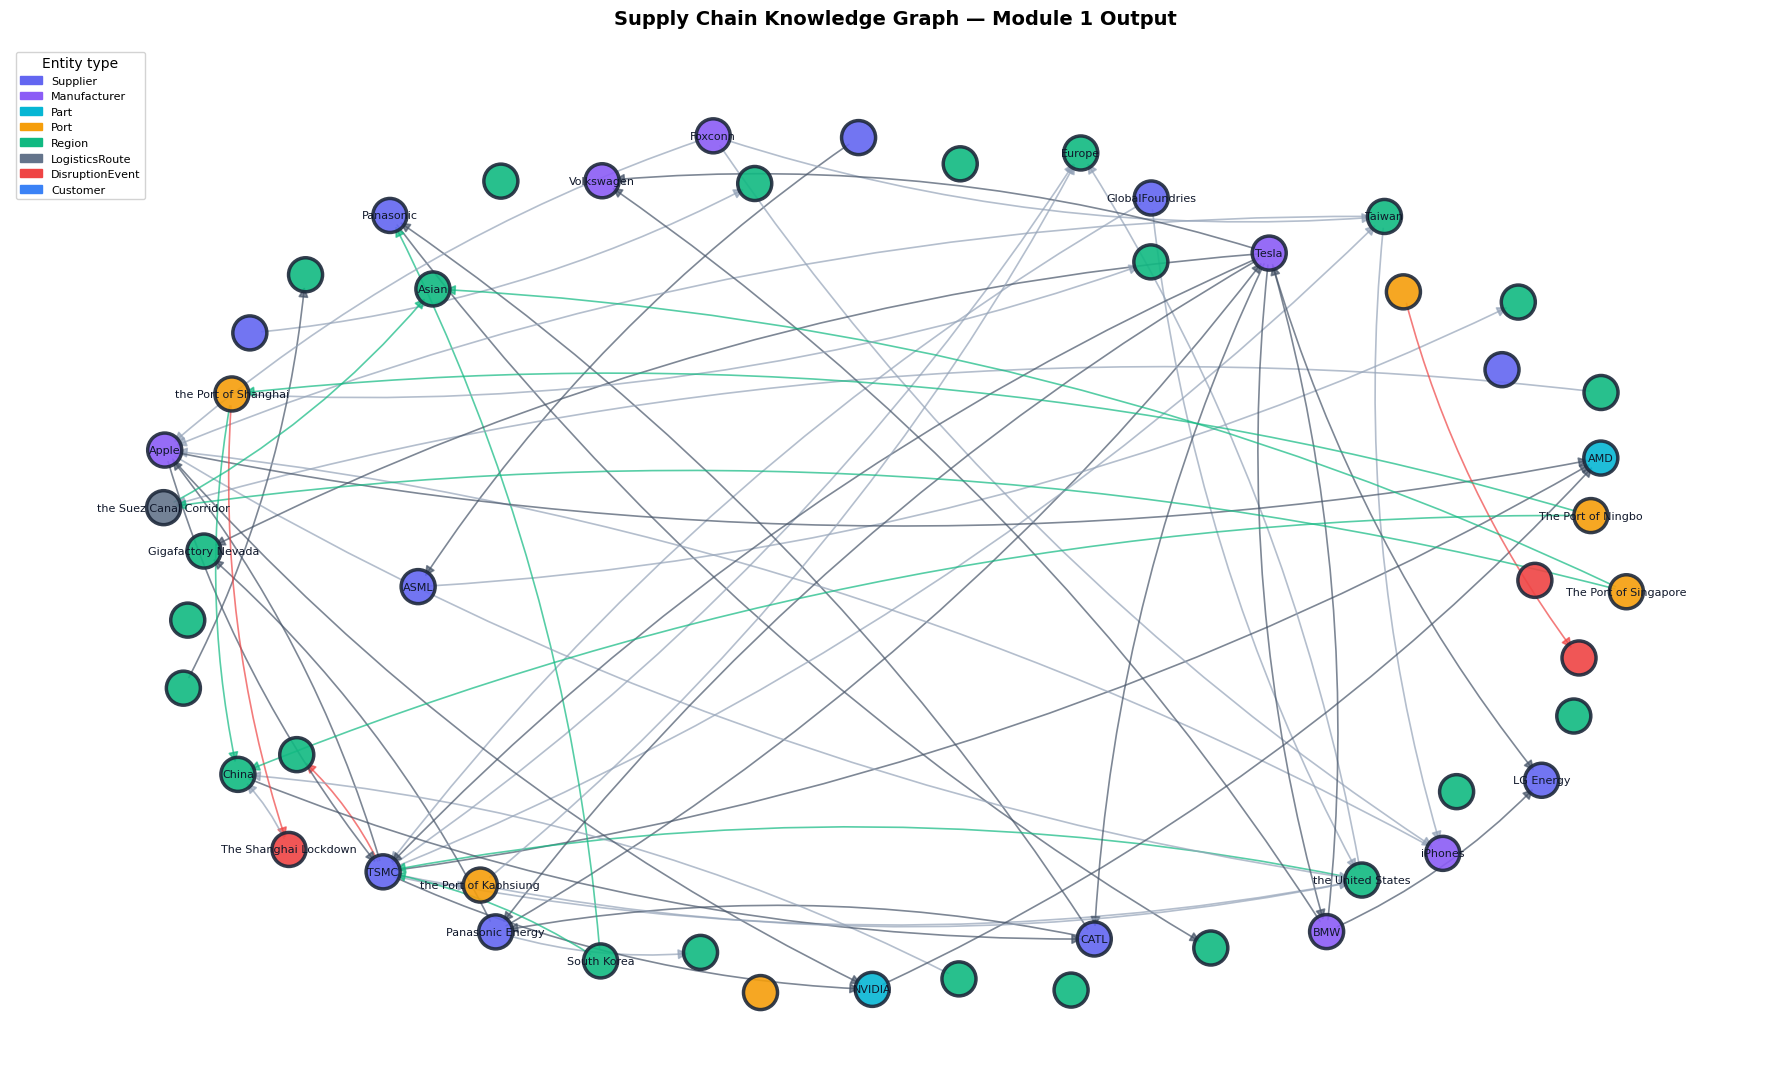

In [16]:
# ── Static matplotlib visualization ──────────────────────────────────────────

plot_graph(
    G,
    title="Supply Chain Knowledge Graph — Module 1 Output",
    figsize=(18, 11),
    save_path=OUTPUTS / "module1_full_graph.png",
)

[Viz] Plot saved → ../outputs/graphs/module1_tsmc_ego.png


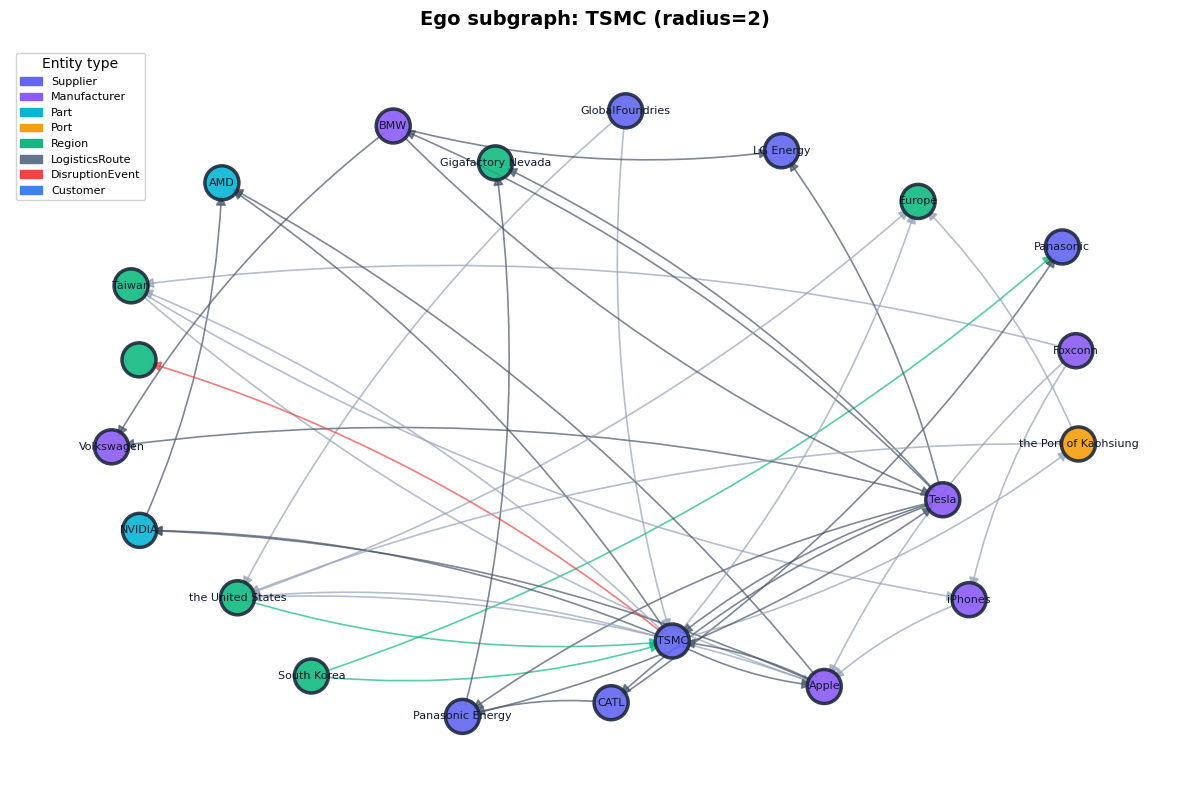

In [17]:
# ── Ego subgraph: TSMC neighbourhood ─────────────────────────────────────────
# Shows TSMC and all nodes within 2 hops — a useful view for Module 3.

plot_ego_subgraph(
    G,
    center_node="TSMC",
    radius=2,
    figsize=(12, 8),
    save_path=OUTPUTS / "module1_tsmc_ego.png",
)

In [18]:
# ── Interactive pyvis visualization ──────────────────────────────────────────
# Generates an HTML file you can open in a browser for the demo.

from src.utils.visualization import plot_graph_interactive

html_path = plot_graph_interactive(
    G,
    title="Supply Chain Knowledge Graph — Interactive",
    save_path=OUTPUTS / "module1_interactive.html",
)

print(f"\n✓ Open in browser: {html_path}")

# Render inline in notebook (works in Jupyter)
from IPython.display import IFrame
IFrame(src=html_path, width="100%", height="600px")

[Viz] Interactive graph saved → ../outputs/graphs/module1_interactive.html

✓ Open in browser: ../outputs/graphs/module1_interactive.html


---

## Step 9 — Persist Outputs for Module 2

In [19]:
# ── Save all processed artifacts ──────────────────────────────────────────────
import pickle

# 1. Graph (NetworkX pickle)
graph_path = DATA_PROCESSED / "graph.gpickle"
#nx.write_gpickle(G, str(graph_path))
with open(graph_path, 'wb') as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)


# 2. Triples JSON
builder.save_triples(DATA_PROCESSED / "triples.json")

# 3. Canonical entity registry JSON
builder.save_entities(DATA_PROCESSED / "entities.json")

# 4. FAISS index (already saved above, confirming)
print(f"\n✓ All Module 1 outputs saved:")
for f in sorted(DATA_PROCESSED.iterdir()):
    size = f.stat().st_size
    print(f"  {f.name:35s} {size:>8,} bytes")

[Builder] Triples saved → ../data/processed/triples.json
[Builder] Entities saved → ../data/processed/entities.json

✓ All Module 1 outputs saved:
  communities.json                       3,649 bytes
  entities.json                         10,379 bytes
  faiss_index.bin                       78,381 bytes
  faiss_index.bin.names                    870 bytes
  graph.gpickle                         90,748 bytes
  retrieval_results.pkl                159,486 bytes
  sim_asml_export_ban.json               2,016 bytes
  sim_congo_cobalt_strike.json           2,399 bytes
  sim_red_sea_disruption.json            1,425 bytes
  sim_shanghai_port_closure.json         2,143 bytes
  sim_taiwan_earthquake.json             2,151 bytes
  simulation_taiwan.pkl                 73,979 bytes
  triples.json                          12,497 bytes


---

## Module 1 — Summary

| Output | Description | Used in |
|--------|-------------|--------|
| `graph.gpickle` | Full NetworkX DiGraph with typed nodes and edges | Modules 2, 3, 4, 5 |
| `triples.json` | All extracted (head, relation, tail) triples | Module 5 evaluation |
| `entities.json` | Canonical entity registry with aliases | Module 2, inspection |
| `faiss_index.bin` | FAISS flat L2 index of node embeddings | Module 2 retrieval |

**GenAI concepts demonstrated:**
- ✅ **Encoder-only model** — spaCy NER for entity extraction
- ✅ **Embeddings** — sentence-transformers for node vector representations
- ✅ **Transformer architecture** — underlying both spaCy and sentence-transformers

**Baseline NLP quality:**
- Recall will be moderate with rule-based extraction — this motivates **Module B**
  (fine-tuning a BERT encoder on SC-specific NER labels) as the improvement step.

**Next:** `02_graphrag_retrieval.ipynb` — load this graph and build the dual
retrieval layer (semantic seed search + K-hop graph traversal + community summaries).